In [88]:
%pip install scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


In [89]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [90]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [91]:
import pandas as pd

df = pd.read_csv("cleaned_data (1).csv")
df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,False,False,True,False,False,False,False,False,False,False


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31671 entries, 0 to 31670
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   31671 non-null  int64  
 1   person_income                31671 non-null  int64  
 2   person_emp_length            31671 non-null  float64
 3   loan_amnt                    31671 non-null  int64  
 4   loan_int_rate                31671 non-null  float64
 5   loan_status                  31671 non-null  int64  
 6   loan_percent_income          31671 non-null  float64
 7   cb_person_cred_hist_length   31671 non-null  int64  
 8   person_home_ownership_OTHER  31671 non-null  bool   
 9   person_home_ownership_OWN    31671 non-null  bool   
 10  person_home_ownership_RENT   31671 non-null  bool   
 11  loan_intent_EDUCATION        31671 non-null  bool   
 12  loan_intent_HOMEIMPROVEMENT  31671 non-null  bool   
 13  loan_intent_MEDI

In [93]:
df.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'person_home_ownership_OTHER',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E',
       'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y'],
      dtype='object')

In [94]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31671.000000,3.167100e+04,31671.000000,31671.000000,31671.000000,31671.000000,31671.000000,31671.000000
mean,27.792239,6.585111e+04,4.662591,9574.321935,0.110201,0.219096,0.170107,5.846105
std,6.216063,5.278995e+04,3.908800,6324.431079,0.032185,0.413641,0.106808,4.073635
min,20.000000,4.000000e+03,0.000000,500.000000,0.054200,0.000000,0.000000,2.000000
25%,23.000000,3.840000e+04,2.000000,5000.000000,0.078800,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,0.109958,0.000000,0.150000,4.000000
75%,30.000000,7.905000e+04,7.000000,12000.000000,0.134646,0.000000,0.230000,8.000000
max,80.000000,2.039784e+06,34.000000,35000.000000,0.232200,1.000000,0.830000,30.000000


In [95]:
age = ctrl.Antecedent(np.arange(20, 81, 1), 'age')
income = ctrl.Antecedent(np.arange(4000, 100000, 1000), 'income') 
loan_amnt = ctrl.Antecedent(np.arange(500, 35001, 500), 'loan_amnt')
loan_status = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'loan_status')

In [96]:
age['young'] = fuzz.trapmf(age.universe, [20, 20, 25, 35]) 
age['middle_aged'] = fuzz.trimf(age.universe, [30, 45, 60]) 
age['senior'] = fuzz.trapmf(age.universe, [55, 70, 80, 80]) 

income['low'] = fuzz.trapmf(income.universe, [4000, 4000, 20000, 40000]) 
income['medium'] = fuzz.trimf(income.universe, [30000, 60000, 90000]) 
income['high'] = fuzz.trapmf(income.universe, [80000, 150000, 1000000, 1000000]) 

loan_amnt['small'] = fuzz.trapmf(loan_amnt.universe, [500, 500, 5000, 15000]) 
loan_amnt['medium'] = fuzz.trimf(loan_amnt.universe, [10000, 20000, 30000]) 
loan_amnt['large'] = fuzz.trapmf(loan_amnt.universe, [25000, 30000, 35000, 35000]) 

loan_status['risky'] = fuzz.trapmf(loan_status.universe, [0,0, 0.3, 0.6])
loan_status['safe'] = fuzz.trapmf(loan_status.universe, [0.4, 0.7, 1,1])

In [97]:
rule1 = ctrl.Rule(income['low'] & loan_amnt['large'], loan_status['risky'])
rule2 = ctrl.Rule(age['young'] & loan_amnt['large'], loan_status['risky'])
rule3 = ctrl.Rule(income['low'] & age['senior'], loan_status['risky']) 

rule4 = ctrl.Rule(income['high'], loan_status['safe']) 
rule5 = ctrl.Rule(income['medium'] & loan_amnt['small'], loan_status['safe'])
rule6 = ctrl.Rule(age['middle_aged'] & income['medium'], loan_status['safe'])

rule7 = ctrl.Rule(income['medium'] & loan_amnt['medium'], loan_status['safe'])
rule8 = ctrl.Rule(age['young'] & income['medium'], loan_status['safe'])

c:\Users\Ahmed Hassan\AppData\Local\Programs\Python\Python313\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


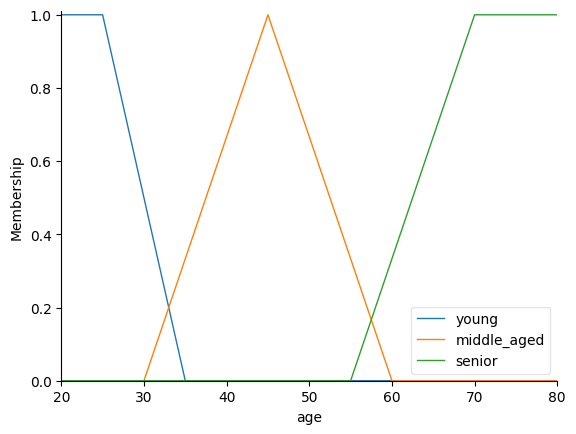

In [98]:
age.view()

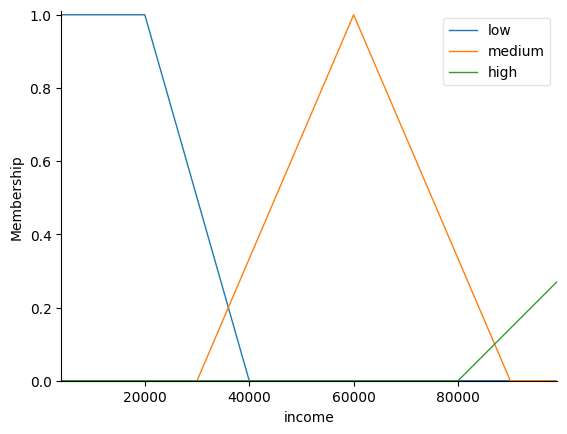

In [99]:
income.view()

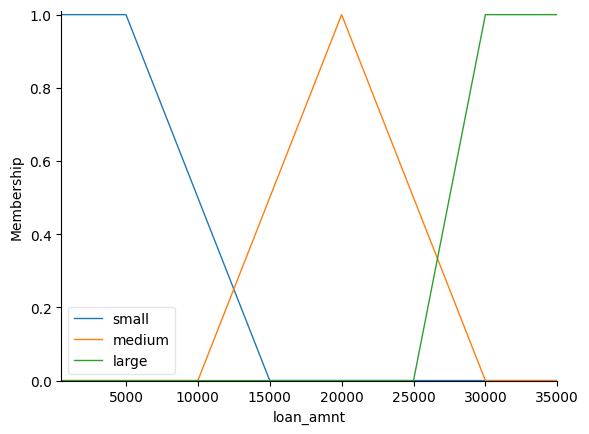

In [100]:
loan_amnt.view()

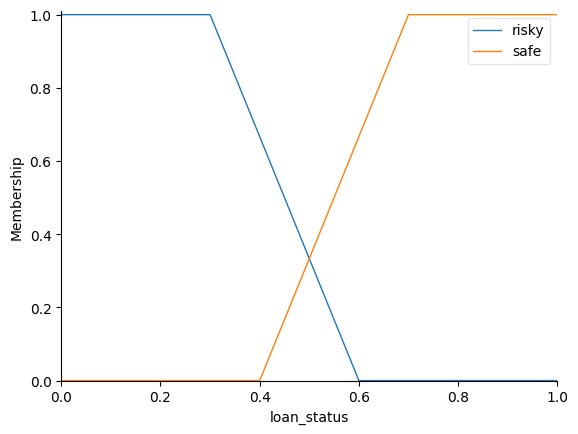

In [101]:
loan_status.view()